# Modelos de referencia y experimentos iniciales

Este cuaderno corresponde a la segunda etapa del proyecto y a la primera parte del objetivo específico 2: implementar el flujo de validación, entrenar los modelos de referencia y realizar los experimentos iniciales que ponen a prueba las hipótesis formuladas en el análisis exploratorio. La búsqueda completa de modelos, con las formulaciones ordinales y los demás algoritmos, se realiza en la etapa siguiente.

Las hipótesis provienen de las secciones 8 a 10 del análisis exploratorio:

| Hipótesis | Enunciado | Comparación |
|---|---|---|
| H1 | El modelo de referencia supera al azar | QWK del modelo entrenado con el conjunto de referencia frente a su distribución con etiquetas permutadas |
| H2 | El conjunto principal alcanza un QWK mayor que el de referencia, con una ganancia que se espera pequeña | Principal frente a referencia |
| H3 | Si el conjunto principal mejora, la mejora proviene de la actigrafía | Principal frente a principal sin actigrafía |
| H4 | El conjunto complementario mejora frente al principal | Complementario frente a principal |

Para que las diferencias reflejen la información que aporta cada conjunto y no el algoritmo, todas las comparaciones usan las mismas dos configuraciones fijas, una regresión logística multinomial y un modelo de gradient boosting, sobre los mismos participantes y las mismas particiones. El cuaderno sigue este orden: datos y conjuntos de variables, esquema de validación, métricas y controles, preprocesamiento, modelo de referencia, experimentos iniciales, desempeño por nivel de severidad y conclusión.

Como en el análisis exploratorio, todas las salidas son agregadas. Las predicciones por participante se usan solo para calcular métricas y no se muestran.

In [23]:
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.dummy import DummyClassifier

from piu_severity.config import FIGURES_DIR, INTERIM_DATA_DIR, RANDOM_SEED
from piu_severity.data.clean import clean_values
from piu_severity.data.load import list_actigraphy_ids, load_train
from piu_severity.evaluation.metrics import SII_LEVELS, as_levels
from piu_severity.evaluation.validation import (
    N_OUTER_REPEATS,
    N_OUTER_SPLITS,
    aggregate_repeats,
    inner_cv,
    mean_confusion_matrix,
    outer_splits,
    paired_differences,
    permutation_null,
    permutation_p_value,
    run_nested_cv,
    split_level_counts,
    summarize_by_repeat,
    summarize_paired,
)
from piu_severity.features.actigraphy import (
    ACTIGRAPHY_FEATURES,
    load_actigraphy_summary,
)
from piu_severity.features.build import build_analytic_dataset
from piu_severity.features.groups import (
    TARGET_COLUMN,
    column_group,
    experiment_feature_sets,
    is_excluded,
    is_instrument_season,
)
from piu_severity.features.preprocessing import build_preprocessor, column_types
from piu_severity.models.pipelines import make_boosting_search, make_logistic_search
from piu_severity.visualization.figures import save_figure

In [2]:
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

FIGURAS = FIGURES_DIR / "02_experimentos_iniciales"

NIVELES_SII = {0: "ninguno", 1: "leve", 2: "moderado", 3: "severo"}
NOMBRES_CONJUNTOS = {
    "reference": "referencia",
    "main": "principal",
    "main_without_actigraphy": "principal sin actigrafía",
    "complementary": "complementario",
}

## 1. Datos y conjuntos de variables

El conjunto de datos analítico se construye con el paquete del proyecto, con los mismos pasos de la sección 10 del análisis exploratorio: depuración de los valores inválidos y recorte a los máximos del protocolo de FitnessGram, fusión de los totales de PAQ-A y PAQ-C e incorporación de las variables de actigrafía de las series utilizables. Como estas reglas son fijas y no se ajustan con los datos, se aplican una sola vez, antes de la validación cruzada.

Los predictores se organizan en dos niveles, definidos en el análisis exploratorio. El primero son los **grupos**, que clasifican cada variable según lo que mide; cada variable pertenece a un solo grupo:

| Grupo | Qué mide |
|---|---|
| Demográfico | Edad, sexo y temporada de inscripción |
| Físico | Medidas antropométricas y signos vitales, aptitud física (FitnessGram), composición corporal (bioimpedancia), actividad física autorreportada (PAQ) y actividad física medida con actigrafía |
| Complementario | Alteraciones del sueño (SDS), funcionamiento global (CGAS) y horas diarias de uso de computador e internet |

El segundo nivel son los **conjuntos**, que combinan grupos y son los que se usan para entrenar los modelos:

| Conjunto | Grupos que incluye | Pregunta que responde |
|---|---|---|
| Referencia | Demográfico | ¿Cuánto se puede estimar el SII solo con la edad, el sexo y la temporada de inscripción? |
| Principal sin actigrafía | Demográfico y físico, sin las variables de actigrafía | ¿Cuánto aportan las variables físicas tabulares por encima de las demográficas? |
| Principal | Demográfico y físico | ¿Cuánto aportan los indicadores físicos por encima de las variables demográficas? Es la pregunta central del proyecto |
| Complementario | Demográfico, físico y complementario | ¿Cuánto cambia el desempeño al añadir medidas psicológicas, conductuales y de uso de internet? |

Los conjuntos de referencia, principal y complementario provienen de la formulación del proyecto. El conjunto principal sin actigrafía se agrega para aislar el aporte de la actigrafía, que es la hipótesis H3. El modelo de referencia es, por tanto, el modelo entrenado con el conjunto de referencia.

Esta sección construye el conjunto de datos analítico y los cuatro conjuntos de variables. Se verifica que los conjuntos estén anidados, que no incluyan el identificador ni las columnas del PCIAT y que su composición coincida con la del análisis exploratorio.

In [3]:
train = load_train()
etiquetados = train[train[TARGET_COLUMN].notna()].reset_index(drop=True)

analitico = build_analytic_dataset(
    clean_values(etiquetados), load_actigraphy_summary(list_actigraphy_ids())
)
y = as_levels(analitico[TARGET_COLUMN])
conjuntos = experiment_feature_sets(analitico.columns)
columnas_actigrafia = list(ACTIGRAPHY_FEATURES.values())

assert len(analitico) == len(etiquetados)
assert analitico["id"].is_unique
assert not any(
    is_excluded(c) or is_instrument_season(c)
    for columnas in conjuntos.values()
    for c in columnas
)
assert (
    set(conjuntos["reference"])
    <= set(conjuntos["main_without_actigraphy"])
    <= set(conjuntos["main"])
    <= set(conjuntos["complementary"])
)
assert set(conjuntos["main"]) - set(conjuntos["main_without_actigraphy"]) == set(
    columnas_actigrafia
)

distribucion_sii = (
    pd.Series(y)
    .map(NIVELES_SII)
    .value_counts()
    .reindex(NIVELES_SII.values())
    .rename_axis("SII")
    .to_frame("participantes")
)
distribucion_sii["%"] = (
    100 * distribucion_sii["participantes"] / distribucion_sii["participantes"].sum()
).round(1)
distribucion_sii

,participantes,%
SII,,
ninguno,1594,58.3
leve,730,26.7
moderado,378,13.8
severo,34,1.2


In [4]:
GRUPOS_ES = {
    "demographic": "demográficas",
    "physical": "físicas",
    "complementary": "complementarias",
}

composicion_conjuntos = pd.DataFrame(
    {
        NOMBRES_CONJUNTOS[nombre]: pd.Series(
            [GRUPOS_ES[column_group(c)] for c in columnas]
        ).value_counts()
        for nombre, columnas in conjuntos.items()
    }
).reindex(GRUPOS_ES.values()).fillna(0).astype(int).T
composicion_conjuntos["total"] = composicion_conjuntos.sum(axis="columns")
composicion_conjuntos["incluye actigrafía"] = [
    "sí" if set(columnas_actigrafia) <= set(columnas) else "no"
    for columnas in conjuntos.values()
]
composicion_conjuntos.index.name = "conjunto"

print(f"Participantes etiquetados: {len(analitico)}")
print(
    "Participantes con variables de actigrafía: "
    f"{int(analitico[columnas_actigrafia].notna().any(axis='columns').sum())}"
)
composicion_conjuntos

Participantes etiquetados: 2736
Participantes con variables de actigrafía: 823


,demográficas,físicas,complementarias,total,incluye actigrafía
conjunto,,,,,
referencia,3,0,0,3,no
principal,3,33,0,36,sí
principal sin actigrafía,3,30,0,33,no
complementario,3,33,3,39,sí


### Conclusión

El conjunto de datos analítico reproduce el del análisis exploratorio: contiene a los 2.736 participantes etiquetados, de los cuales 823 tienen variables de actigrafía, y conserva la distribución del SII (58,3 % ninguno, 26,7 % leve, 13,8 % moderado y 1,2 % severo, con 34 casos severos).

| Conjunto | Demográficas | Físicas | Complementarias | Total | Incluye actigrafía |
|---|---|---|---|---|---|
| Referencia | 3 | 0 | 0 | 3 | No |
| Principal sin actigrafía | 3 | 30 | 0 | 33 | No |
| Principal | 3 | 33 | 0 | 36 | Sí |
| Complementario | 3 | 33 | 3 | 39 | Sí |

Cada fila indica cuántas variables de cada grupo contiene el conjunto. Los cuatro conjuntos están anidados en el orden de la tabla y ninguno incluye el identificador, las columnas del PCIAT ni las temporadas de instrumento. Con esta estructura, cada hipótesis compara dos conjuntos que difieren en un solo bloque de variables: H2, todas las variables físicas; H3, solo la actigrafía; y H4, las variables complementarias.

## 2. Esquema de validación

Cada modelo requiere dos decisiones que deben tomarse con datos distintos: elegir sus hiperparámetros, como la intensidad de la regularización, y medir su desempeño en participantes que no vio durante el entrenamiento. Si ambas se hicieran con los mismos datos, el desempeño estimado sería optimista, porque los hiperparámetros elegidos serían los que mejor se ajustan precisamente a esos participantes. Para separarlas se usa validación cruzada anidada, que tiene dos niveles.

**Nivel externo: medición del desempeño.** Los 2.736 participantes se dividen en cinco partes de tamaño similar, estratificadas por SII para que cada parte conserve la proporción de cada nivel de severidad. Se hacen cinco vueltas: en cada una, una de las partes se aparta como partición de evaluación y las otras cuatro forman la partición de entrenamiento. Al terminar, cada participante se ha evaluado exactamente una vez.

**Nivel interno: elección de hiperparámetros.** Dentro de cada partición de entrenamiento externa, y solo con esos participantes, se repite el mismo procedimiento con tres partes. Cada combinación candidata de hiperparámetros se entrena con dos partes y se evalúa con la tercera, rotando tres veces, y se elige la de mejor QWK promedio. Con esa combinación, el modelo se reentrena con toda la partición de entrenamiento externa y se evalúa en la partición de evaluación externa, que no intervino en ninguna decisión de ajuste.

| Nivel | Qué participantes se dividen | Partes | Participantes para entrenar | Participantes para evaluar | Uso |
|---|---|---|---|---|---|
| Externo | Los 2.736 participantes | 5 | Alrededor de 2.189 (cuatro de las cinco partes) | Alrededor de 547 (una parte) | Medir el desempeño |
| Interno | Los participantes de entrenamiento de una partición externa | 3 | Alrededor de 1.459 (dos de las tres partes) | Alrededor de 730 (una parte) | Elegir los hiperparámetros |

El nivel externo se repite cinco veces, con una división distinta de los participantes en cada repetición; la repetición r usa la semilla base más r. Esto da 25 particiones externas y reduce la dependencia de los resultados respecto de una sola forma de dividir los datos. Como todas las configuraciones y todos los conjuntos de variables se evalúan sobre las mismas 25 particiones, las comparaciones entre ellos se pueden hacer de forma pareada, sobre los mismos participantes.

Esta sección construye las particiones y verifica tres propiedades: que cada participante se evalúe exactamente una vez en cada repetición, que la estratificación mantenga la proporción de cada nivel de SII y cuántos casos de cada nivel contiene cada partición de evaluación, externa e interna. Este último conteo condiciona la estabilidad de las métricas del nivel severo.

In [5]:
particiones = outer_splits(y)

for repeticion in range(N_OUTER_REPEATS):
    evaluados = np.concatenate([p.test for p in particiones if p.repeat == repeticion])
    assert np.array_equal(np.sort(evaluados), np.arange(len(y)))
assert all(np.intersect1d(p.train, p.test).size == 0 for p in particiones)

tamanos_evaluacion = pd.Series([len(p.test) for p in particiones])
print(
    f"Particiones externas: {len(particiones)} "
    f"({N_OUTER_SPLITS} particiones × {N_OUTER_REPEATS} repeticiones)"
)
print(
    "Participantes por partición externa de evaluación: "
    f"entre {tamanos_evaluacion.min()} y {tamanos_evaluacion.max()}"
)

Particiones externas: 25 (5 particiones × 5 repeticiones)
Participantes por partición externa de evaluación: entre 547 y 548


In [6]:
casos_externos = split_level_counts(particiones, y)

filas_internas = []
for particion in particiones:
    y_entrenamiento = y[particion.train]
    for _, evaluacion_interna in inner_cv().split(
        np.zeros(len(y_entrenamiento)), y_entrenamiento
    ):
        conteo = pd.Series(y_entrenamiento[evaluacion_interna]).value_counts()
        filas_internas.append(conteo.reindex(SII_LEVELS, fill_value=0))
casos_internos = pd.DataFrame(filas_internas)

casos_por_particion = pd.concat(
    {
        "partición externa": casos_externos.agg(["min", "mean", "max"]).T,
        "partición interna": casos_internos.agg(["min", "mean", "max"]).T,
    },
    axis="columns",
).rename(index=NIVELES_SII, columns={"min": "mínimo", "mean": "media", "max": "máximo"})
casos_por_particion.index.name = "SII"

print(f"Particiones internas de evaluación: {len(casos_internos)}")
casos_por_particion.round(1)

Particiones internas de evaluación: 75


partición externa               partición interna              
                    mínimo  media máximo            mínimo  media máximo
SII                                                                     
ninguno              318.0  318.8  319.0             425.0  425.1  426.0
leve                 146.0  146.0  146.0             194.0  194.7  195.0
moderado              75.0   75.6   76.0             100.0  100.8  101.0
severo                 6.0    6.8    7.0               9.0    9.1   10.0

### Conclusión

#### Verificación de las particiones

Se generaron 25 particiones externas: cinco particiones en cada una de las cinco repeticiones. Cumplen las dos verificaciones: en cada repetición, cada participante se evalúa exactamente una vez, y ninguna partición comparte participantes entre entrenamiento y evaluación. Cada partición externa de evaluación contiene 547 o 548 participantes.

#### Casos de cada nivel por partición

Hay dos tipos de partición de evaluación. Las **externas** (25) miden el desempeño final de cada modelo. Las **internas** (75, tres dentro de cada partición externa) se usan solo para elegir los hiperparámetros, y se forman con los participantes de entrenamiento de la partición externa.

| SII | Casos en cada partición externa | Casos en cada partición interna |
|---|---|---|
| Ninguno | 318 o 319 | Entre 425 y 426 |
| Leve | 146 | Entre 194 y 195 |
| Moderado | 75 o 76 | Entre 100 y 101 |
| Severo | 6 o 7 | Entre 9 y 10 |

La tabla se lee por filas: por ejemplo, cada partición externa contiene 6 o 7 participantes con SII severo. En todos los niveles, el número de casos varía como máximo en uno entre particiones, de modo que la estratificación es prácticamente exacta y las diferencias de desempeño entre particiones no se deben a cambios en la proporción de los niveles.

#### Consecuencias para la evaluación

El nivel severo es el que limita la estabilidad de las estimaciones. Con 6 o 7 casos por partición externa, el recall de ese nivel calculado en una sola partición solo puede variar en saltos de alrededor de 14 puntos porcentuales: detectar un caso más o un caso menos cambia el resultado en esa magnitud. Por eso las métricas, que se definen en la sección siguiente, se calculan de dos formas:

- **QWK, por partición.** Así se obtienen 25 valores que permiten comparar dos configuraciones de forma pareada, sobre los mismos participantes.
- **Recall por nivel, tasa de subestimación y matriz de confusión, sobre las predicciones acumuladas de cada repetición.** Como en cada repetición todos los participantes se evalúan una vez, estas métricas usan los 34 casos severos y no solo los 6 o 7 de una partición.

En la validación interna, cada partición de evaluación conserva 9 o 10 casos severos. La selección de hiperparámetros se apoya, por tanto, en más casos de los que tendría con cinco particiones internas (alrededor de 5), aunque sigue dependiendo de pocos participantes de ese nivel.

## 3. Métricas y controles de cordura

El desempeño se mide con cuatro métricas, definidas en la formulación del proyecto:

- **QWK (quadratic weighted kappa).** Mide la concordancia entre el nivel real y el estimado, y penaliza cada error en proporción al cuadrado de la distancia entre ambos niveles. Vale 1 con concordancia perfecta y 0 cuando la concordancia equivale a la esperada por azar, dadas las distribuciones de los niveles reales y estimados. Es la métrica principal.
- **Recall por nivel** (sensibilidad). Proporción de participantes de cada nivel que el modelo asigna a ese mismo nivel; en el nivel severo, por ejemplo, es la proporción de casos severos identificados como severos.
- **Tasa de subestimación.** Proporción de participantes con PIU moderado o severo a los que se asigna un nivel inferior al real; se reporta también solo para el nivel severo, donde equivale a 1 menos su recall, porque cualquier error con un caso severo consiste en asignarle un nivel inferior. Complementa al QWK, que penaliza igual sobrestimar que subestimar, cuando en un tamizaje el error más costoso es subestimar un caso moderado o severo.
- **Matriz de confusión.** Distribución de los niveles estimados para cada nivel real.

Como se definió en la sección anterior, el QWK se calcula en cada partición externa y se promedia dentro de cada repetición; las demás métricas se calculan sobre las predicciones acumuladas de cada repetición. En adelante, los resultados se reportan como media ± desviación estándar entre las cinco repeticiones.

Antes de entrenar modelos, el flujo de evaluación se verifica con dos clasificadores que no usan los predictores:

- **Clase mayoritaria.** Asigna a todos los participantes el nivel más frecuente en la partición de entrenamiento. Por construcción, su QWK es 0.
- **Aleatorio estratificado.** Asigna niveles al azar con las proporciones de la partición de entrenamiento. Su QWK esperado también es 0, aunque varía entre particiones.

Estos dos clasificadores cumplen dos funciones: verifican que la evaluación produzca los valores esperados para un modelo sin información, y constituyen el primer nivel de la jerarquía de modelos de referencia, que cualquier modelo útil debe superar.

In [7]:
CONTROLES = {
    "clase mayoritaria": DummyClassifier(strategy="most_frequent"),
    "aleatorio estratificado": DummyClassifier(
        strategy="stratified", random_state=RANDOM_SEED
    ),
}
X_referencia = analitico[conjuntos["reference"]]

resultados_controles = {
    nombre: run_nested_cv(modelo, X_referencia, y, particiones)
    for nombre, modelo in CONTROLES.items()
}

In [15]:
METRICAS_ES = {
    "qwk": "QWK",
    "recall_0": "recall ninguno",
    "recall_1": "recall leve",
    "recall_2": "recall moderado",
    "recall_3": "recall severo",
    "underestimation": "subestimación moderado o severo",
    "underestimation_severe": "subestimación severo",
}


def tabla_desempeno(resultados: dict) -> pd.DataFrame:
    """Resume cada modelo con la media y la desviación entre repeticiones."""
    filas = {}
    for nombre, (pliegues, predicciones) in resultados.items():
        agregado = aggregate_repeats(summarize_by_repeat(pliegues, predicciones))
        filas[nombre] = {
            (METRICAS_ES[metrica], estadistico): agregado.at[metrica, columna]
            for metrica in METRICAS_ES
            for estadistico, columna in [("media", "mean"), ("desv.", "std")]
        }
    tabla = pd.DataFrame(filas).T
    tabla.columns = pd.MultiIndex.from_tuples(tabla.columns)
    return tabla


tabla_controles = tabla_desempeno(resultados_controles)
qwk_por_particion = pd.DataFrame(
    {nombre: pliegues["qwk"] for nombre, (pliegues, _) in resultados_controles.items()}
).agg(["min", "max"]).T.rename(columns={"min": "QWK mínimo", "max": "QWK máximo"})

display(tabla_controles.round(3))
qwk_por_particion.round(3)

QWK        recall ninguno        recall leve         \
                        media  desv.          media  desv.       media  desv.   
clase mayoritaria        0.00  0.000          1.000  0.000       0.000  0.000   
aleatorio estratificado -0.01  0.022          0.586  0.011       0.273  0.021   

                        recall moderado        recall severo         \
                                  media  desv.         media  desv.   
clase mayoritaria                 0.000  0.000         0.000  0.000   
aleatorio estratificado           0.123  0.025         0.006  0.013   

                        subestimación moderado o severo         \
                                                  media  desv.   
clase mayoritaria                                 1.000  0.000   
aleatorio estratificado                           0.874  0.022   

                        subestimación severo         
                                       media  desv.  
clase mayoritaria                      1.000  0.000  
aleatorio estratificado                0.994  0.013

,QWK mínimo,QWK máximo
clase mayoritaria,0.000,0.000
aleatorio estratificado,-0.078,0.082


### Conclusión

Los dos controles producen los valores esperados para clasificadores sin información, lo que confirma que la evaluación sobre las particiones funciona correctamente.

| Métrica | Clase mayoritaria | Aleatorio estratificado |
|---|---|---|
| QWK | 0,000 ± 0,000 | −0,010 ± 0,022 |
| QWK por partición (mínimo y máximo) | 0,000 y 0,000 | −0,078 y 0,082 |
| Recall ninguno | 1,000 ± 0,000 | 0,586 ± 0,011 |
| Recall leve | 0,000 ± 0,000 | 0,273 ± 0,021 |
| Recall moderado | 0,000 ± 0,000 | 0,123 ± 0,025 |
| Recall severo | 0,000 ± 0,000 | 0,006 ± 0,013 |
| Subestimación moderado o severo | 1,000 ± 0,000 | 0,874 ± 0,022 |
| Subestimación severo | 1,000 ± 0,000 | 0,994 ± 0,013 |

- **Clase mayoritaria.** Asigna el nivel ninguno a todos los participantes: su recall es 1 en ese nivel y 0 en los demás, subestima a todos los participantes con PIU moderado o severo y su QWK es exactamente 0 en las 25 particiones.
- **Aleatorio estratificado.** Su recall en cada nivel coincide con la proporción de ese nivel en los datos (58,3 %, 26,7 %, 13,8 % y 1,2 %), como corresponde a asignaciones al azar con esas proporciones, y su QWK medio es prácticamente 0.

El control aleatorio establece además el margen de variación que produce el azar: sin ninguna información, el QWK de una sola partición varió entre −0,078 y 0,082. Una diferencia de esa magnitud entre dos modelos en una partición aislada no indica por sí sola una mejora, y por eso las comparaciones entre configuraciones se basan en las 25 diferencias pareadas.

Por último, un modelo sin información subestima a casi 9 de cada 10 participantes con PIU moderado o severo, porque la mayoría de sus asignaciones corresponden a los niveles más frecuentes. Ese es el punto de partida frente al cual se juzga la subestimación de los modelos entrenados, y justifica la ponderación de las clases durante el entrenamiento.

## 4. Preprocesamiento

Las dos configuraciones de los experimentos requieren un preprocesamiento distinto, definido en las secciones 4 a 6 del análisis exploratorio:

- **Regresión logística.** No admite valores faltantes y es sensible a la escala de las variables. Las variables numéricas se imputan con la mediana y se transforman con Yeo-Johnson y estandarización; las ordinales se imputan con la moda y se estandarizan, sin transformarlas, para conservar la distancia entre sus niveles; las binarias se imputan con la moda. Como la imputación asigna el mismo valor a todos los participantes sin datos, se agrega un indicador por instrumento que vale 1 cuando el participante no tiene ningún dato de ese instrumento. Así, el modelo puede distinguir un valor imputado de uno medido.
- **Gradient boosting.** Admite valores faltantes de forma nativa: en cada división del árbol, los participantes sin dato se envían a la rama que más reduce la pérdida. Por eso las variables se usan sin imputar ni transformar, y sin indicadores de ausencia, ya que el propio modelo aprende a tratar la ausencia.

En ambos casos, la temporada de inscripción se codifica con una variable binaria por categoría. Todos los parámetros del preprocesamiento (medianas, modas, transformaciones y estandarización) se ajustan solo con la partición de entrenamiento, dentro del mismo flujo que el modelo, y se aplican después a la partición de evaluación.

Esta sección aplica los dos preprocesamientos a cada conjunto de variables, ajustándolos con la partición de entrenamiento de la primera partición externa y transformando su partición de evaluación. Se verifica la composición de las columnas resultantes, el número de indicadores por conjunto y que la regresión logística no reciba valores faltantes.

In [9]:
PREPROCESAMIENTOS = {
    "regresión logística": ("linear", "simple"),
    "gradient boosting": ("tree", "native"),
}
particion_ejemplo = particiones[0]

filas = []
indicadores_por_conjunto = {}
for nombre, columnas in conjuntos.items():
    X = analitico[columnas]
    tipos = column_types(columnas)
    for configuracion, (familia, estrategia) in PREPROCESAMIENTOS.items():
        preprocesador = build_preprocessor(columnas, familia, estrategia)
        preprocesador.fit(X.iloc[particion_ejemplo.train])
        salida = preprocesador.transform(X.iloc[particion_ejemplo.test])
        indicadores = [c for c in salida.columns if c.startswith("missing_")]
        if indicadores:
            indicadores_por_conjunto[NOMBRES_CONJUNTOS[nombre]] = indicadores
        filas.append(
            {
                "conjunto": NOMBRES_CONJUNTOS[nombre],
                "configuración": configuracion,
                "numéricas": len(tipos["numeric"]),
                "binarias": len(tipos["binary"]),
                "ordinales": len(tipos["ordinal"]),
                "nominales": len(tipos["nominal"]),
                "columnas de temporada": sum(
                    c.startswith("Basic_Demos-Enroll_Season") for c in salida.columns
                ),
                "indicadores de ausencia": len(indicadores),
                "columnas de salida": salida.shape[1],
                "% de celdas faltantes en la salida": round(
                    100 * salida.isna().to_numpy().mean(), 1
                ),
            }
        )

composicion_preprocesamiento = pd.DataFrame(filas).set_index(
    ["conjunto", "configuración"]
)
composicion_preprocesamiento

numéricas  binarias  ordinales  \
conjunto                 configuración                                         
referencia               regresión logística          1         1          0   
                         gradient boosting            1         1          0   
principal                regresión logística         25         6          4   
                         gradient boosting           25         6          4   
principal sin actigrafía regresión logística         22         6          4   
                         gradient boosting           22         6          4   
complementario           regresión logística         27         6          5   
                         gradient boosting           27         6          5   

                                              nominales  \
conjunto                 configuración                    
referencia               regresión logística          1   
                         gradient boosting            1   
principal                regresión logística          1   
                         gradient boosting            1   
principal sin actigrafía regresión logística          1   
                         gradient boosting            1   
complementario           regresión logística          1   
                         gradient boosting            1   

                                              columnas de temporada  \
conjunto                 configuración                                
referencia               regresión logística                      4   
                         gradient boosting                        4   
principal                regresión logística                      4   
                         gradient boosting                        4   
principal sin actigrafía regresión logística                      4   
                         gradient boosting                        4   
complementario           regresión logística                      4   
                         gradient boosting                        4   

                                              indicadores de ausencia  \
conjunto                 configuración                                  
referencia               regresión logística                        0   
                         gradient boosting                          0   
principal                regresión logística                        5   
                         gradient boosting                          0   
principal sin actigrafía regresión logística                        4   
                         gradient boosting                          0   
complementario           regresión logística                        8   
                         gradient boosting                          0   

                                              columnas de salida  \
conjunto                 configuración                             
referencia               regresión logística                   6   
                         gradient boosting                     6   
principal                regresión logística                  44   
                         gradient boosting                    39   
principal sin actigrafía regresión logística                  40   
                         gradient boosting                    36   
complementario           regresión logística                  50   
                         gradient boosting                    42   

                                              % de celdas faltantes en la salida  
conjunto                 configuración                                            
referencia               regresión logística                                 0.0  
                         gradient boosting                                   0.0  
principal                regresión logística                                 0.0  
                         gradient boosting                                  31.1  
principal sin actigrafía regresió

In [10]:
with pd.option_context("display.max_colwidth", None):
    display(
        pd.Series(
            {
                conjunto: ", ".join(n.removeprefix("missing_") for n in nombres)
                for conjunto, nombres in indicadores_por_conjunto.items()
            },
            name="instrumentos con indicador de ausencia",
        ).to_frame()
    )

,instrumentos con indicador de ausencia
principal,"Physical, FGC, BIA, PAQ, Actigraphy"
principal sin actigrafía,"Physical, FGC, BIA, PAQ"
complementario,"CGAS, Physical, FGC, BIA, SDS, PreInt_EduHx, PAQ, Actigraphy"


### Conclusión

Los dos preprocesamientos producen las columnas esperadas en los cuatro conjuntos, y la composición por tipo coincide con la del análisis exploratorio: 27 numéricas, 6 binarias, 5 ordinales y 1 nominal en el conjunto complementario.

| Conjunto | Predictores de entrada | Columnas de salida, regresión logística | Columnas de salida, gradient boosting | Indicadores de ausencia | Celdas faltantes en la salida de gradient boosting |
|---|---|---|---|---|---|
| Referencia | 3 | 6 | 6 | 0 | 0,0 % |
| Principal sin actigrafía | 33 | 40 | 36 | 4 | 27,8 % |
| Principal | 36 | 44 | 39 | 5 | 31,1 % |
| Complementario | 39 | 50 | 42 | 8 | 29,5 % |

Cada fila resume cómo se transforma un conjunto en cada configuración. Las columnas de salida de gradient boosting son los predictores de entrada más tres columnas adicionales, porque la temporada de inscripción se convierte en cuatro variables binarias. La regresión logística agrega además un indicador por instrumento.

- **Indicadores de ausencia.** Se crean para los instrumentos que pueden faltar: medidas físicas, FitnessGram, bioimpedancia, PAQ y actigrafía en el conjunto principal; los mismos sin actigrafía en el principal sin actigrafía; y, en el complementario, además el SDS, el CGAS y las horas de uso de internet. Las variables demográficas (edad, sexo y temporada de inscripción) no tienen indicador porque están completas en todos los participantes: un indicador de ausencia valdría 0 para todos y no aportaría información. Por la misma razón, el conjunto de referencia, que solo contiene variables demográficas, no tiene indicadores.
- **Valores faltantes.** La salida de la regresión logística no contiene valores faltantes en ningún conjunto. En gradient boosting, entre el 27,8 % y el 31,1 % de las celdas siguen faltantes y llegan así al modelo, que las maneja de forma nativa. Esa proporción refleja la ausencia por bloques de los instrumentos descrita en el análisis exploratorio.

Como el preprocesamiento se ajusta con la partición de entrenamiento y solo se aplica a la de evaluación, los valores de imputación y los parámetros de las transformaciones no usan información de los participantes evaluados.

## 5. Modelo de referencia y prueba de H1

El modelo de referencia usa solo las tres variables demográficas: edad, sexo y temporada de inscripción. Se entrena con las dos configuraciones de los experimentos:

- **Regresión logística multinomial**, con el preprocesamiento lineal de la sección anterior. La intensidad de la regularización C se elige en la validación interna entre seis valores, de 0,001 a 100.
- **Gradient boosting** con manejo nativo de faltantes. En la validación interna se elige el número de iteraciones (100 o 300) y el número máximo de hojas por árbol (7 o 15), con una tasa de aprendizaje fija de 0,05.

Ambas ponderan las clases de forma inversamente proporcional a su frecuencia en cada partición de entrenamiento, y ambas eligen sus hiperparámetros por el QWK de la validación interna.

La hipótesis H1 plantea que el modelo de referencia supera al azar. Se pone a prueba con una prueba de permutación: las etiquetas de SII se reordenan al azar, lo que rompe cualquier relación con los predictores pero conserva la distribución de los niveles, y se repite el mismo procedimiento de entrenamiento y evaluación. Con 200 permutaciones se obtiene la distribución del QWK cuando no existe relación entre las variables y el SII. El valor p es la proporción de permutaciones que alcanzan un QWK igual o mayor que el observado, (1 + número de permutaciones con QWK igual o mayor) / (1 + 200). Para que el QWK observado y el de las permutaciones sean comparables, ambos se calculan con el mismo procedimiento: las cinco particiones de la primera repetición. La prueba se aplica a la regresión logística, porque repetir 200 veces la búsqueda de gradient boosting tiene un costo alto y H1 se refiere a la información de las variables demográficas, no al algoritmo.

In [11]:
CONFIGURACIONES = {
    "regresión logística": make_logistic_search,
    "gradient boosting": make_boosting_search,
}

resultados = {}
for configuracion, construir_modelo in CONFIGURACIONES.items():
    columnas = conjuntos["reference"]
    resultados[(configuracion, "reference")] = run_nested_cv(
        construir_modelo(columnas, n_jobs=-1), analitico[columnas], y, particiones
    )

In [16]:
def hiperparametros_elegidos(pliegues: pd.DataFrame) -> pd.Series:
    """Cuenta cuántas particiones externas eligieron cada combinación."""
    return (
        pliegues["best_params"]
        .map(
            lambda parametros: ", ".join(
                f"{clave.removeprefix('model__')} = {valor}"
                for clave, valor in parametros.items()
            )
        )
        .value_counts()
        .rename("particiones")
    )


modelos_referencia = {
    f"{configuracion} (referencia)": resultados[(configuracion, "reference")]
    for configuracion in CONFIGURACIONES
}
display(tabla_desempeno({**resultados_controles, **modelos_referencia}).round(3))

for nombre, (pliegues, _) in modelos_referencia.items():
    print(f"{nombre}: {pliegues['fit_seconds'].sum():.0f} s de entrenamiento en total")
    display(hiperparametros_elegidos(pliegues).to_frame())

QWK        recall ninguno         \
                                  media  desv.          media  desv.   
clase mayoritaria                 0.000  0.000          1.000  0.000   
aleatorio estratificado          -0.010  0.022          0.586  0.011   
regresión logística (referencia)  0.311  0.004          0.646  0.005   
gradient boosting (referencia)    0.302  0.005          0.643  0.009   

                                 recall leve        recall moderado         \
                                       media  desv.           media  desv.   
clase mayoritaria                      0.000  0.000           0.000  0.000   
aleatorio estratificado                0.273  0.021           0.123  0.025   
regresión logística (referencia)       0.208  0.013           0.238  0.011   
gradient boosting (referencia)         0.235  0.011           0.211  0.024   

                                 recall severo         \
                                         media  desv.   
clase mayoritaria                        0.000  0.000   
aleatorio estratificado                  0.006  0.013   
regresión logística (referencia)         0.582  0.048   
gradient boosting (referencia)           0.324  0.072   

                                 subestimación moderado o severo         \
                                                           media  desv.   
clase mayoritaria                                          1.000  0.000   
aleatorio estratificado                                    0.874  0.022   
regresión logística (referencia)                           0.387  0.005   
gradient boosting (referencia)                             0.466  0.010   

                                 subestimación severo         
                                                media  desv.  
clase mayoritaria                               1.000  0.000  
aleatorio estratificado                         0.994  0.013  
regresión logística (referencia)                0.418  0.048  
gradient boosting (referencia)                  0.676  0.072

regresión logística (referencia): 6 s de entrenamiento en total


,particiones
best_params,
C = 0.1,9
C = 1.0,7
C = 10.0,7
C = 100.0,1
C = 0.01,1


gradient boosting (referencia): 28 s de entrenamiento en total


,particiones
best_params,
"max_iter = 100, max_leaf_nodes = 7",19
"max_iter = 100, max_leaf_nodes = 15",3
"max_iter = 300, max_leaf_nodes = 7",3


In [13]:
N_PERMUTACIONES = 200

pliegues_logistica, _ = resultados[("regresión logística", "reference")]
qwk_observado = pliegues_logistica.loc[pliegues_logistica["repeat"] == 0, "qwk"].mean()

qwk_nulo = permutation_null(
    make_logistic_search(conjuntos["reference"]),
    X_referencia,
    y,
    n_permutations=N_PERMUTACIONES,
)
valor_p = permutation_p_value(qwk_observado, qwk_nulo)

pd.Series(
    {
        "QWK observado (primera repetición)": qwk_observado,
        "QWK nulo: media": qwk_nulo.mean(),
        "QWK nulo: percentil 95": np.percentile(qwk_nulo, 95),
        "QWK nulo: máximo": qwk_nulo.max(),
        "valor p": valor_p,
    },
    name="prueba de permutación",
).round(4).to_frame()

,prueba de permutación
QWK observado (primera repetición),0.3103
QWK nulo: media,0.0004
QWK nulo: percentil 95,0.0158
QWK nulo: máximo,0.0359
valor p,0.0050


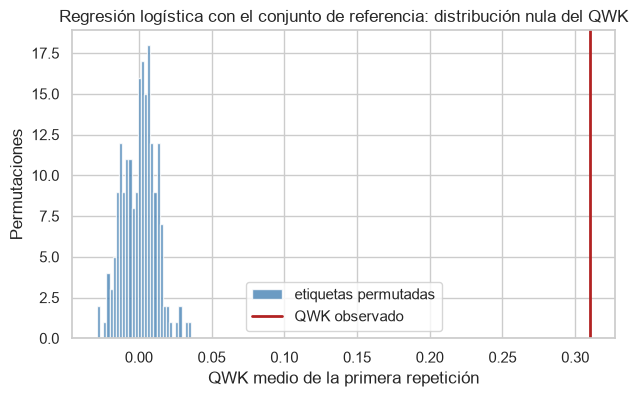

In [14]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(qwk_nulo, bins=30, color="steelblue", alpha=0.8, label="etiquetas permutadas")
ax.axvline(qwk_observado, color="firebrick", linewidth=2, label="QWK observado")
ax.set(
    xlabel="QWK medio de la primera repetición",
    ylabel="Permutaciones",
    title="Regresión logística con el conjunto de referencia: distribución nula del QWK",
)
ax.legend()
save_figure(fig, "h1_permutacion_referencia", FIGURAS)
plt.show()

### Conclusión

#### Desempeño del modelo de referencia

Con solo la edad, el sexo y la temporada de inscripción, las dos configuraciones superan con claridad a los controles de la sección 3:

| Métrica | Aleatorio estratificado | Regresión logística | Gradient boosting |
|---|---|---|---|
| QWK | −0,010 ± 0,022 | 0,311 ± 0,004 | 0,302 ± 0,005 |
| Recall ninguno | 0,586 ± 0,011 | 0,646 ± 0,005 | 0,643 ± 0,009 |
| Recall leve | 0,273 ± 0,021 | 0,208 ± 0,013 | 0,235 ± 0,011 |
| Recall moderado | 0,123 ± 0,025 | 0,238 ± 0,011 | 0,211 ± 0,024 |
| Recall severo | 0,006 ± 0,013 | 0,582 ± 0,048 | 0,324 ± 0,072 |
| Subestimación moderado o severo | 0,874 ± 0,022 | 0,387 ± 0,005 | 0,466 ± 0,010 |
| Subestimación severo | 0,994 ± 0,013 | 0,418 ± 0,048 | 0,676 ± 0,072 |

- **QWK.** Las dos configuraciones alcanzan un QWK de alrededor de 0,30, con una diferencia entre ellas de 0,009, del orden de su variación entre repeticiones. Con tres variables, un modelo más flexible no aporta sobre uno lineal.
- **Desempeño por nivel.** La ponderación de las clases desplaza las asignaciones hacia los niveles altos: frente al clasificador aleatorio, el recall aumenta en los niveles moderado y severo, y la subestimación de los participantes con PIU moderado o severo baja de 0,874 a 0,387 con la regresión logística. El costo recae en el nivel leve, cuyo recall queda por debajo del clasificador aleatorio: con la edad y el sexo, el modelo distingue los extremos de la severidad mejor que los niveles intermedios.
- **Nivel severo.** La regresión logística identifica en promedio 0,582 de los casos severos, alrededor de 20 de 34, y gradient boosting 0,324, alrededor de 11. La diferencia es grande frente a su variación entre repeticiones, pero se apoya en 34 participantes, por lo que se toma como una observación preliminar y no como una ventaja establecida de una configuración sobre la otra.

#### Hiperparámetros elegidos y costo

- **Regresión logística.** La intensidad de la regularización elegida varía entre particiones, de C = 0,01 a C = 100, con la mayoría entre 0,1 y 10. Con solo tres predictores, el QWK interno cambia poco con C, por lo que la elección es inestable sin afectar el desempeño.
- **Gradient boosting.** En 19 de las 25 particiones se eligió la combinación más simple, 100 iteraciones y 7 hojas por árbol, coherente con el poco detalle que pueden aportar tres variables.
- **Costo.** El entrenamiento completo, con la búsqueda interna, tomó 6 segundos con la regresión logística y 28 con gradient boosting, lo que hace viables los experimentos de la sección siguiente con los conjuntos de mayor tamaño.

#### Prueba de H1

| Indicador | Valor |
|---|---|
| QWK observado de la regresión logística (primera repetición) | 0,310 |
| QWK con etiquetas permutadas: media | 0,000 |
| QWK con etiquetas permutadas: percentil 95 | 0,016 |
| QWK con etiquetas permutadas: máximo en 200 permutaciones | 0,036 |
| Valor p | 0,005 |

Ninguna de las 200 permutaciones alcanzó un QWK cercano al observado: el máximo fue 0,036, frente a 0,310. El valor p de 0,005 es el mínimo posible con 200 permutaciones, 1/201, de modo que el valor real podría ser aún menor. La figura muestra la distribución nula concentrada alrededor de 0 y el QWK observado muy por encima de ella.

**La hipótesis H1 se sostiene:** el modelo de referencia supera al azar. La edad y el sexo contienen información sobre la severidad del PIU, como anticipaba el análisis exploratorio, y un QWK de alrededor de 0,31 es el desempeño que los conjuntos con variables físicas deben superar para aportar información adicional.

## 6. Experimentos iniciales: H2, H3 y H4

Las dos configuraciones de la sección anterior se entrenan con los tres conjuntos restantes, sobre las mismas 25 particiones. Cada hipótesis compara dos conjuntos que difieren en un solo bloque de variables:

| Hipótesis | Conjunto evaluado | Conjunto de comparación | Bloque que se agrega |
|---|---|---|---|
| H2 | Principal | Referencia | Todas las variables físicas |
| H3 | Principal | Principal sin actigrafía | Las tres variables de actigrafía |
| H4 | Complementario | Principal | Sueño, funcionamiento global y horas de internet |

Para cada hipótesis y cada configuración se calcula la diferencia de QWK entre los dos conjuntos en cada una de las 25 particiones. Como ambos modelos se evalúan sobre los mismos participantes, la diferencia elimina la variación que se debe a qué participantes cayeron en cada partición. Las diferencias se resumen de tres formas:

- **Diferencia media y desviación estándar**, que miden la magnitud de la mejora y su estabilidad.
- **Número de particiones con mejora**, de 25.
- **Prueba t corregida de Nadeau y Bengio**, unilateral, que evalúa si la diferencia media es mayor que cero. La prueba t usual supone que las 25 diferencias son independientes, pero no lo son: los conjuntos de entrenamiento de las distintas particiones comparten la mayoría de sus participantes, lo que hace que la varianza de la diferencia media se subestime. La corrección multiplica la varianza por (1/25 + n_evaluación/n_entrenamiento) en lugar de 1/25.

Como se hacen seis pruebas (tres hipótesis por dos configuraciones), los valores p se ajustan además con el procedimiento de Holm, que controla la probabilidad de cometer al menos un falso positivo entre las seis. Los valores p se usan como complemento: la evidencia principal es la magnitud de la diferencia y su consistencia entre particiones.

In [18]:
CONJUNTOS_RESTANTES = ["main_without_actigraphy", "main", "complementary"]

for conjunto in CONJUNTOS_RESTANTES:
    columnas = conjuntos[conjunto]
    for configuracion, construir_modelo in CONFIGURACIONES.items():
        resultados[(configuracion, conjunto)] = run_nested_cv(
            construir_modelo(columnas, n_jobs=-1), analitico[columnas], y, particiones
        )

ARCHIVO_RESULTADOS = INTERIM_DATA_DIR / "02_experimentos_iniciales_resultados.joblib"
joblib.dump(resultados, ARCHIVO_RESULTADOS)

['/Users/juan/Documents/Maestria/PrimerSemestre/ProyectoInvestigacionI/repos/piu-severity-prediction/data/interim/02_experimentos_iniciales_resultados.joblib']

In [19]:
ORDEN_CONJUNTOS = ["reference", "main_without_actigraphy", "main", "complementary"]

filas = []
for configuracion in CONFIGURACIONES:
    for conjunto in ORDEN_CONJUNTOS:
        pliegues, predicciones = resultados[(configuracion, conjunto)]
        agregado = aggregate_repeats(summarize_by_repeat(pliegues, predicciones))
        filas.append(
            {
                "configuración": configuracion,
                "conjunto": NOMBRES_CONJUNTOS[conjunto],
                "QWK media": agregado.at["qwk", "mean"],
                "QWK desv.": agregado.at["qwk", "std"],
                "QWK mínimo por partición": pliegues["qwk"].min(),
                "QWK máximo por partición": pliegues["qwk"].max(),
                "entrenamiento total (s)": pliegues["fit_seconds"].sum(),
            }
        )

pd.DataFrame(filas).set_index(["configuración", "conjunto"]).round(3)

QWK media  QWK desv.  \
configuración       conjunto                                         
regresión logística referencia                    0.311      0.004   
                    principal sin actigrafía      0.308      0.003   
                    principal                     0.308      0.005   
                    complementario                0.384      0.011   
gradient boosting   referencia                    0.302      0.005   
                    principal sin actigrafía      0.310      0.011   
                    principal                     0.315      0.007   
                    complementario                0.393      0.008   

                                              QWK mínimo por partición  \
configuración       conjunto                                             
regresión logística referencia                                   0.280   
                    principal sin actigrafía                     0.253   
                    principal                                    0.246   
                    complementario                               0.316   
gradient boosting   referencia                                   0.235   
                    principal sin actigrafía                     0.233   
                    principal                                    0.256   
                    complementario                               0.307   

                                              QWK máximo por partición  \
configuración       conjunto                                             
regresión logística referencia                                   0.340   
                    principal sin actigrafía                     0.354   
                    principal                                    0.359   
                    complementario                               0.440   
gradient boosting   referencia                                   0.333   
                    principal sin actigrafía                     0.385   
                    principal                                    0.381   
                    complementario                               0.477   

                                              entrenamiento total (s)  
configuración       conjunto                                           
regresión logística referencia                                  6.022  
                    principal sin actigrafía                   32.696  
                    principal                                  25.790  
                    complementario                             28.260  
gradient boosting   referencia                                 27.708  
                    principal sin actigrafía                   72.038  
                    principal                                  80.884  
                    complementario                             84.179

In [20]:
COMPARACIONES = {
    "H2": ("main", "reference"),
    "H3": ("main", "main_without_actigraphy"),
    "H4": ("complementary", "main"),
}

filas = []
diferencias_largas = []
for hipotesis, (evaluado, comparacion) in COMPARACIONES.items():
    for configuracion in CONFIGURACIONES:
        diferencias = paired_differences(
            resultados[(configuracion, evaluado)][0],
            resultados[(configuracion, comparacion)][0],
        )
        resumen = summarize_paired(diferencias)
        filas.append(
            {
                "hipótesis": hipotesis,
                "comparación": (
                    f"{NOMBRES_CONJUNTOS[evaluado]} frente a "
                    f"{NOMBRES_CONJUNTOS[comparacion]}"
                ),
                "configuración": configuracion,
                "diferencia media de QWK": resumen["mean_difference"],
                "desviación de la diferencia": resumen["std_difference"],
                "particiones con mejora": (
                    f"{resumen['folds_improved']} de {resumen['n_folds']}"
                ),
                "t corregido": resumen["corrected_t"],
                "valor p unilateral": resumen["p_value_one_sided"],
            }
        )
        diferencias_largas.append(
            pd.DataFrame(
                {
                    "hipótesis": hipotesis,
                    "configuración": configuracion,
                    "diferencia de QWK": diferencias["difference"],
                }
            )
        )

comparaciones = pd.DataFrame(filas)
valores_p = comparaciones["valor p unilateral"]
orden = valores_p.sort_values().index
factores_holm = np.arange(len(valores_p), 0, -1)
comparaciones["valor p ajustado (Holm)"] = (
    (valores_p.loc[orden] * factores_holm).cummax().clip(upper=1).reindex(valores_p.index)
)
comparaciones.set_index(["hipótesis", "configuración"]).round(4)

comparación  \
hipótesis configuración                                                      
H2        regresión logística                principal frente a referencia   
          gradient boosting                  principal frente a referencia   
H3        regresión logística  principal frente a principal sin actigrafía   
          gradient boosting    principal frente a principal sin actigrafía   
H4        regresión logística            complementario frente a principal   
          gradient boosting              complementario frente a principal   

                               diferencia media de QWK  \
hipótesis configuración                                  
H2        regresión logística                  -0.0032   
          gradient boosting                     0.0138   
H3        regresión logística                   0.0000   
          gradient boosting                     0.0055   
H4        regresión logística                   0.0763   
          gradient boosting                     0.0775   

                               desviación de la diferencia  \
hipótesis configuración                                      
H2        regresión logística                       0.0230   
          gradient boosting                         0.0307   
H3        regresión logística                       0.0128   
          gradient boosting                         0.0226   
H4        regresión logística                       0.0266   
          gradient boosting                         0.0335   

                              particiones con mejora  t corregido  \
hipótesis configuración                                             
H2        regresión logística               11 de 25      -0.2579   
          gradient boosting                 17 de 25       0.8371   
H3        regresión logística               11 de 25       0.0028   
          gradient boosting                 15 de 25       0.4542   
H4        regresión logística               25 de 25       5.3333   
          gradient boosting                 25 de 25       4.2960   

                               valor p unilateral  valor p ajustado (Holm)  
hipótesis configuración                                                     
H2        regresión logística              0.6007                   0.9978  
          gradient boosting                0.2054                   0.8216  
H3        regresión logística              0.4989                   0.9978  
          gradient boosting                0.3269                   0.9807  
H4        regresión logística              0.0000                   0.0001  
          gradient boosting                0.0001                   0.0006

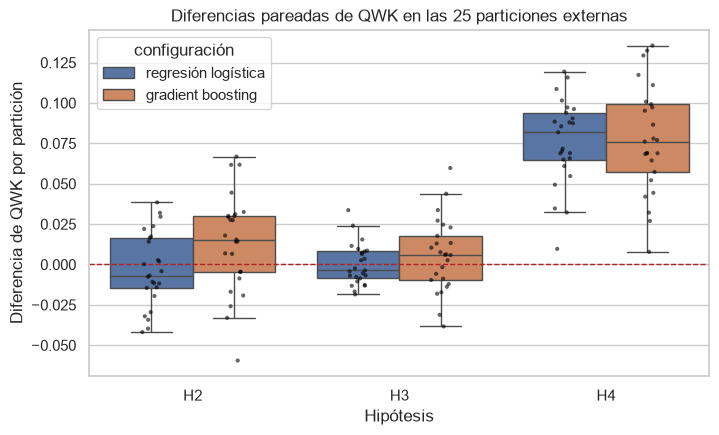

In [22]:
diferencias_por_particion = pd.concat(diferencias_largas, ignore_index=True)

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.boxplot(
    data=diferencias_por_particion,
    x="hipótesis",
    y="diferencia de QWK",
    hue="configuración",
    showfliers=False,
    ax=ax,
)
sns.stripplot(
    data=diferencias_por_particion,
    x="hipótesis",
    y="diferencia de QWK",
    hue="configuración",
    dodge=True,
    palette=["black"] * len(CONFIGURACIONES),
    size=3,
    alpha=0.6,
    legend=False,
    ax=ax,
)
ax.axhline(0, color="firebrick", linewidth=1, linestyle="--")
ax.set(
    xlabel="Hipótesis",
    ylabel="Diferencia de QWK por partición",
    title="Diferencias pareadas de QWK en las 25 particiones externas",
)
save_figure(fig, "diferencias_pareadas_hipotesis", FIGURAS)
plt.show()

### Conclusión

#### Resultado de las hipótesis

| Hipótesis | Pregunta | Resultado |
|---|---|---|
| H2 | ¿Las variables físicas mejoran el QWK frente al conjunto de referencia? | No se sostiene: la mejora no se distingue de cero |
| H3 | ¿La actigrafía explica la mejora del conjunto principal? | No se sostiene: retirar la actigrafía no cambia el QWK |
| H4 | ¿Las variables complementarias mejoran el QWK frente al conjunto principal? | Se sostiene: la mejora es de alrededor de 0,08 y aparece en todas las particiones |

#### QWK de cada conjunto

| Conjunto | Regresión logística | Gradient boosting |
|---|---|---|
| Referencia | 0,311 ± 0,004 | 0,302 ± 0,005 |
| Principal sin actigrafía | 0,308 ± 0,003 | 0,310 ± 0,011 |
| Principal | 0,308 ± 0,005 | 0,315 ± 0,007 |
| Complementario | 0,384 ± 0,011 | 0,393 ± 0,008 |

Los tres primeros conjuntos obtienen prácticamente el mismo QWK, alrededor de 0,31, con ambas configuraciones. Es decir, agregar las variables físicas a la edad, el sexo y la temporada no cambia el desempeño. Solo el conjunto complementario se separa, con un QWK de alrededor de 0,39.

#### Diferencias pareadas

Para cada hipótesis se resta, partición por partición, el QWK del conjunto de comparación al del conjunto evaluado. Una diferencia positiva indica que el conjunto evaluado fue mejor en esa partición. La tabla resume las 25 diferencias de cada comparación:

- **Diferencia media:** la ganancia promedio de QWK, con la desviación estándar de las 25 diferencias después del ±.
- **Particiones con mejora:** en cuántas de las 25 particiones la diferencia fue positiva. Si no hubiera ningún efecto, se esperarían alrededor de 12 o 13.
- **Valor p ajustado:** probabilidad de observar una ganancia media igual o mayor si en realidad no hubiera mejora, calculada con la prueba t corregida y ajustada por el número de comparaciones.

| Hipótesis | Configuración | Diferencia media de QWK | Particiones con mejora | Valor p ajustado (Holm) |
|---|---|---|---|---|
| H2: principal − referencia | Regresión logística | −0,003 ± 0,023 | 11 de 25 | 0,998 |
| H2: principal − referencia | Gradient boosting | 0,014 ± 0,031 | 17 de 25 | 0,822 |
| H3: principal − principal sin actigrafía | Regresión logística | 0,000 ± 0,013 | 11 de 25 | 0,998 |
| H3: principal − principal sin actigrafía | Gradient boosting | 0,006 ± 0,023 | 15 de 25 | 0,981 |
| H4: complementario − principal | Regresión logística | 0,076 ± 0,027 | 25 de 25 | Menor que 0,001 |
| H4: complementario − principal | Gradient boosting | 0,078 ± 0,034 | 25 de 25 | Menor que 0,001 |

La figura muestra las mismas diferencias. En H2 y H3, las cajas quedan a ambos lados de cero; en H4, todas las diferencias son positivas.

#### Interpretación

**H2.** Las variables físicas no mejoran el QWK de forma detectable. Con la regresión logística, la diferencia es prácticamente cero y el conjunto principal gana en menos de la mitad de las particiones. Con gradient boosting, la diferencia es positiva (0,014) y gana en 17 de 25 particiones, pero la ganancia es menor que su variación entre particiones y el valor p ajustado es 0,82. Con esta variabilidad, la prueba podría detectar ganancias de alrededor de 0,02 a 0,03 de QWK; una ganancia menor no se puede descartar, pero tampoco se observa. El resultado coincide con el análisis exploratorio: la asociación de las variables físicas con el SII desaparecía al controlar por la edad y el sexo. Lo que esas variables informan sobre el SII ya lo contiene el modelo de referencia a través de la edad.

**H3.** Retirar la actigrafía no cambia el QWK: la diferencia es 0,000 con la regresión logística y 0,006 con gradient boosting, sin consistencia entre particiones. La hipótesis, además, suponía una mejora del conjunto principal que no ocurrió. La asociación del ENMO diurno con el SII que mostró el análisis exploratorio no se traduce, por tanto, en mejor desempeño. Una explicación posible es la cobertura: solo el 30 % de los participantes tiene una serie utilizable, y solo 6 de los 34 casos severos, de modo que su información pesa poco en el conjunto completo.

**H4.** Las variables complementarias mejoran el QWK en 0,076 con la regresión logística y en 0,078 con gradient boosting, alrededor de un 25 % sobre el conjunto principal. La mejora aparece en las 25 particiones con ambas configuraciones, y los valores p ajustados son menores que 0,001. Coincide con el análisis exploratorio, en el que las horas de uso de internet y el SDS mantenían su asociación con el SII al controlar por la edad y el sexo.

#### Configuraciones y costo

Con los conjuntos principal y complementario, gradient boosting obtiene un QWK algo mayor que la regresión logística: 0,315 frente a 0,308, y 0,393 frente a 0,384. La regresión logística no gana nada al agregar las variables físicas, e incluso pierde ligeramente; una explicación posible es que las 33 variables y los 5 indicadores agregan varianza sin aportar información nueva. Estas diferencias entre configuraciones son pequeñas y no se evaluaron formalmente; la comparación entre algoritmos corresponde a la búsqueda de modelos de la etapa siguiente. Entrenar una configuración con un conjunto tomó como máximo 84 segundos con gradient boosting y 33 con la regresión logística.

## 7. Desempeño por nivel de severidad

El QWK resume la concordancia en un solo valor, pero no muestra en qué niveles acierta o falla el modelo. Para un tamizaje importa en particular qué ocurre con los participantes con PIU moderado o severo. Esta sección compara, para las dos configuraciones y los cuatro conjuntos, el recall de cada nivel y la tasa de subestimación, y presenta las matrices de confusión de las predicciones acumuladas.

En las matrices, cada fila corresponde a un nivel real y se normaliza para que sume 1: cada celda indica la proporción de participantes de ese nivel a los que el modelo asigna cada nivel estimado, y la diagonal es el recall. Las matrices se promedian entre las cinco repeticiones. Como complemento, se muestra cómo se reparten en promedio los 34 casos severos entre los niveles estimados.

El recall no indica cuántas veces el modelo asigna un nivel sin que corresponda. Por eso se calcula también la **precision** de cada nivel (precisión): la proporción de participantes asignados a un nivel que realmente pertenecen a él. Además, como en un tamizaje un caso severo estimado como moderado igualmente sería remitido, se calcula la proporción de participantes moderados o severos que el modelo asigna a uno de esos dos niveles.

El análisis es preliminar: usa las dos configuraciones fijas de los experimentos, y el análisis por nivel del modelo seleccionado se realiza en la etapa siguiente.

In [24]:
def tabla_por_nivel(configuracion: str) -> pd.DataFrame:
    """Resume el recall y la subestimación de una configuración en cada conjunto."""
    columnas = {}
    for conjunto in ORDEN_CONJUNTOS:
        pliegues, predicciones = resultados[(configuracion, conjunto)]
        agregado = aggregate_repeats(summarize_by_repeat(pliegues, predicciones))
        columnas[NOMBRES_CONJUNTOS[conjunto]] = {
            METRICAS_ES[metrica]: (
                f"{agregado.at[metrica, 'mean']:.3f} ± {agregado.at[metrica, 'std']:.3f}"
            )
            for metrica in METRICAS_ES
            if metrica != "qwk"
        }
    return pd.DataFrame(columnas)


for configuracion in CONFIGURACIONES:
    print(configuracion)
    display(tabla_por_nivel(configuracion))

regresión logística


,referencia,principal sin actigrafía,principal,complementario
recall ninguno,0.646 ± 0.005,0.616 ± 0.002,0.613 ± 0.009,0.653 ± 0.007
recall leve,0.208 ± 0.013,0.237 ± 0.012,0.253 ± 0.006,0.282 ± 0.014
recall moderado,0.238 ± 0.011,0.327 ± 0.021,0.329 ± 0.025,0.380 ± 0.020
recall severo,0.582 ± 0.048,0.576 ± 0.049,0.594 ± 0.038,0.571 ± 0.068
subestimación moderado o severo,0.387 ± 0.005,0.425 ± 0.012,0.427 ± 0.012,0.421 ± 0.025
subestimación severo,0.418 ± 0.048,0.424 ± 0.049,0.406 ± 0.038,0.429 ± 0.068


gradient boosting


,referencia,principal sin actigrafía,principal,complementario
recall ninguno,0.643 ± 0.009,0.649 ± 0.004,0.655 ± 0.003,0.682 ± 0.008
recall leve,0.235 ± 0.011,0.281 ± 0.010,0.281 ± 0.010,0.329 ± 0.009
recall moderado,0.211 ± 0.024,0.338 ± 0.026,0.353 ± 0.028,0.386 ± 0.040
recall severo,0.324 ± 0.072,0.171 ± 0.025,0.153 ± 0.025,0.171 ± 0.025
subestimación moderado o severo,0.466 ± 0.010,0.612 ± 0.024,0.608 ± 0.025,0.574 ± 0.050
subestimación severo,0.676 ± 0.072,0.829 ± 0.025,0.847 ± 0.025,0.829 ± 0.025


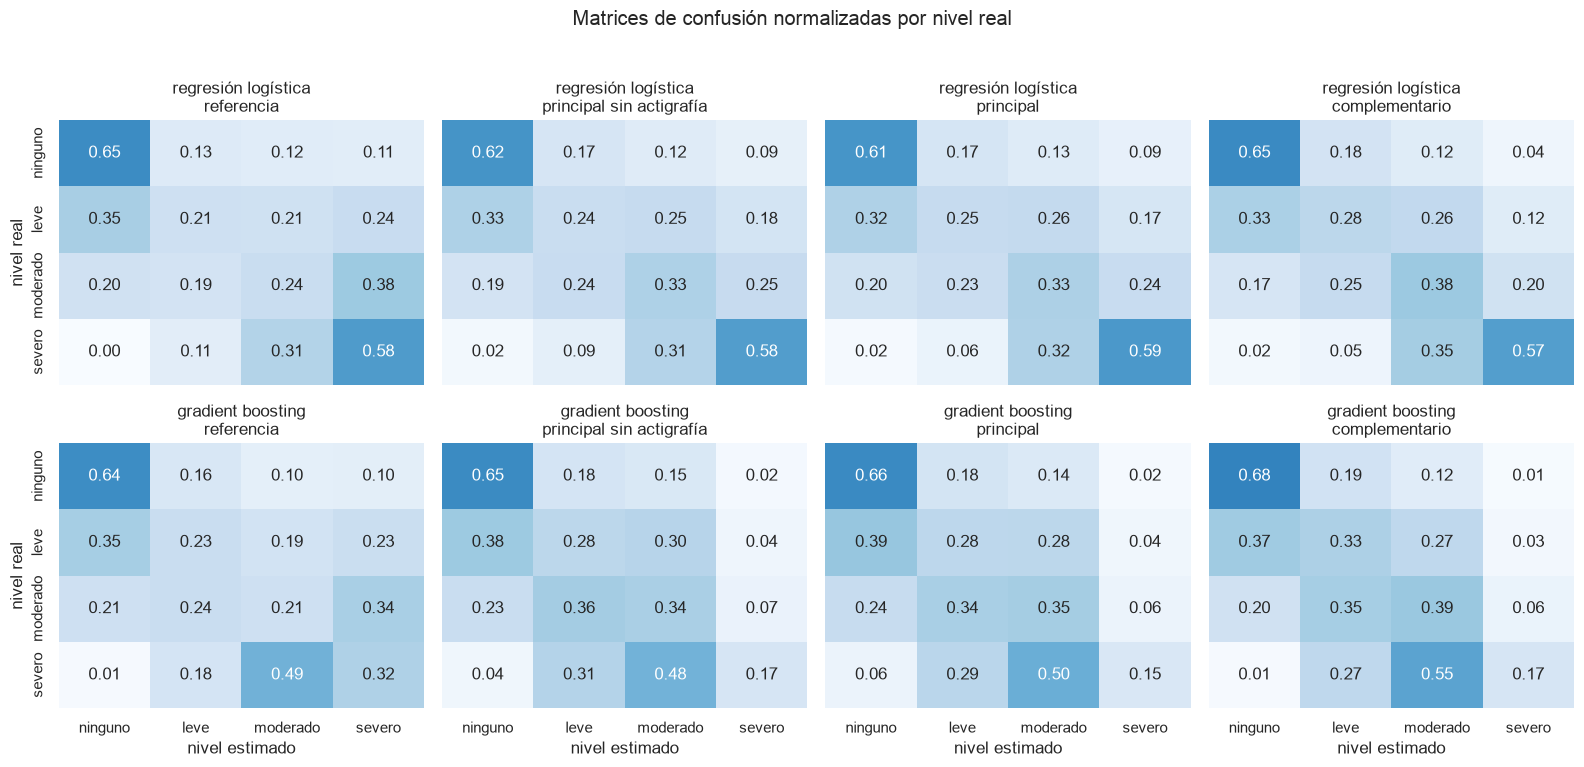

In [25]:
ETIQUETAS_NIVEL = list(NIVELES_SII.values())

fig, ejes = plt.subplots(
    len(CONFIGURACIONES), len(ORDEN_CONJUNTOS), figsize=(16, 7.5), sharex=True, sharey=True
)
for fila, configuracion in enumerate(CONFIGURACIONES):
    for columna, conjunto in enumerate(ORDEN_CONJUNTOS):
        _, predicciones = resultados[(configuracion, conjunto)]
        matriz = mean_confusion_matrix(predicciones)
        ax = ejes[fila, columna]
        sns.heatmap(
            matriz,
            annot=True,
            fmt=".2f",
            vmin=0,
            vmax=1,
            cmap="Blues",
            cbar=False,
            xticklabels=ETIQUETAS_NIVEL,
            yticklabels=ETIQUETAS_NIVEL,
            ax=ax,
        )
        ax.set(
            title=f"{configuracion}\n{NOMBRES_CONJUNTOS[conjunto]}",
            xlabel="nivel estimado" if fila == len(CONFIGURACIONES) - 1 else "",
            ylabel="nivel real" if columna == 0 else "",
        )
fig.suptitle("Matrices de confusión normalizadas por nivel real", y=1.02)
fig.tight_layout()
save_figure(fig, "matrices_confusion_por_conjunto", FIGURAS)
plt.show()

In [26]:
destino_severos = pd.DataFrame(
    {
        (configuracion, NOMBRES_CONJUNTOS[conjunto]): mean_confusion_matrix(
            resultados[(configuracion, conjunto)][1], normalize=False
        ).loc[3]
        for configuracion in CONFIGURACIONES
        for conjunto in ORDEN_CONJUNTOS
    }
).T.rename(columns=NIVELES_SII)
destino_severos.index.names = ["configuración", "conjunto"]
destino_severos.columns.name = "nivel estimado"
destino_severos.round(1)

nivel estimado                                ninguno  leve  moderado  severo
configuración       conjunto                                                 
regresión logística referencia                    0.0   3.6      10.6    19.8
                    principal sin actigrafía      0.8   3.2      10.4    19.6
                    principal                     0.6   2.2      11.0    20.2
                    complementario                0.8   1.8      12.0    19.4
gradient boosting   referencia                    0.4   6.0      16.6    11.0
                    principal sin actigrafía      1.4  10.4      16.4     5.8
                    principal                     2.0   9.8      17.0     5.2
                    complementario                0.4   9.2      18.6     5.8

In [27]:
filas = []
for configuracion in CONFIGURACIONES:
    for conjunto in ORDEN_CONJUNTOS:
        conteos = mean_confusion_matrix(
            resultados[(configuracion, conjunto)][1], normalize=False
        )
        asignados = conteos.sum(axis="index")
        precision = pd.Series(np.diag(conteos), index=conteos.columns) / asignados
        altos = [2, 3]
        filas.append(
            {
                "configuración": configuracion,
                "conjunto": NOMBRES_CONJUNTOS[conjunto],
                **{f"asignados {NIVELES_SII[n]}": asignados[n] for n in SII_LEVELS},
                **{f"precision {NIVELES_SII[n]}": precision[n] for n in SII_LEVELS},
                "moderados o severos asignados a moderado o severo": (
                    conteos.loc[altos, altos].to_numpy().sum()
                    / conteos.loc[altos].to_numpy().sum()
                ),
                "severos asignados a moderado o severo": (
                    conteos.loc[3, altos].sum() / conteos.loc[3].sum()
                ),
            }
        )

asignaciones_y_precision = pd.DataFrame(filas).set_index(["configuración", "conjunto"])
with pd.option_context("display.max_columns", None):
    display(asignaciones_y_precision.round(3))

asignados ninguno  \
configuración       conjunto                                      
regresión logística referencia                           1356.4   
                    principal sin actigrafía             1292.4   
                    principal                            1288.0   
                    complementario                       1348.2   
gradient boosting   referencia                           1359.0   
                    principal sin actigrafía             1398.4   
                    principal                            1425.2   
                    complementario                       1434.2   

                                              asignados leve  \
configuración       conjunto                                   
regresión logística referencia                         431.0   
                    principal sin actigrafía           538.8   
                    principal                          552.6   
                    complementario                     596.6   
gradient boosting   referencia                         516.6   
                    principal sin actigrafía           635.8   
                    principal                          636.2   
                    complementario                     687.2   

                                              asignados moderado  \
configuración       conjunto                                       
regresión logística referencia                             434.8   
                    principal sin actigrafía               518.2   
                    principal                              525.6   
                    complementario                         537.2   
gradient boosting   referencia                             388.2   
                    principal sin actigrafía               603.6   
                    principal                              586.6   
                    complementario                         549.8   

                                              asignados severo  \
configuración       conjunto                                     
regresión logística referencia                           513.8   
                    principal sin actigrafía             386.6   
                    principal                            369.8   
                    complementario                       254.0   
gradient boosting   referencia                           472.2   
                    principal sin actigrafía              98.2   
                    principal                             88.0   
                    complementario                        64.8   

                                              precision ninguno  \
configuración       conjunto                                      
regresión logística referencia                            0.759   
                    principal sin actigrafía              0.760   
                    principal                             0.759   
                    complementario                        0.772   
gradient boosting   referencia                            0.754   
                    principal sin actigrafía              0.739   
                    principal                             0.733   
                    complementario                        0.758   

                                              precision leve  \
configuración       conjunto                                   
regresión logística referencia                         0.352   
                    principal sin actigrafía           0.321   
                    principal                          0.334   
                    complementario                     0.345   
gradient boosting   referencia                         0.332   
                    principal sin actigrafía           0.323   
                    principal                          0.322   
                    complementario                     0.349   

                                              precision moderado  \
configuració

### Conclusión

La tabla resume los resultados con los conjuntos de referencia, principal y complementario. El conjunto principal sin actigrafía se omite porque sus valores son prácticamente iguales a los del principal. Para que la tabla sea legible se muestran solo las medias entre repeticiones; las desviaciones están en las salidas de las celdas anteriores.

| Métrica | Regresión logística: referencia | Regresión logística: principal | Regresión logística: complementario | Gradient boosting: referencia | Gradient boosting: principal | Gradient boosting: complementario |
|---|---|---|---|---|---|---|
| Recall ninguno | 0,646 | 0,613 | 0,653 | 0,643 | 0,655 | 0,682 |
| Recall leve | 0,208 | 0,253 | 0,282 | 0,235 | 0,281 | 0,329 |
| Recall moderado | 0,238 | 0,329 | 0,380 | 0,211 | 0,353 | 0,386 |
| Recall severo | 0,582 | 0,594 | 0,571 | 0,324 | 0,153 | 0,171 |
| Subestimación moderado o severo | 0,387 | 0,427 | 0,421 | 0,466 | 0,608 | 0,574 |
| Subestimación severo | 0,418 | 0,406 | 0,429 | 0,676 | 0,847 | 0,829 |
| Participantes asignados a severo | 514 | 370 | 254 | 472 | 88 | 65 |
| Precision severo | 0,039 | 0,055 | 0,076 | 0,023 | 0,059 | 0,090 |
| Moderados o severos asignados a moderado o severo | 0,638 | 0,600 | 0,608 | 0,575 | 0,433 | 0,471 |
| Severos asignados a moderado o severo | 0,894 | 0,918 | 0,924 | 0,812 | 0,653 | 0,718 |

#### Dos formas opuestas de tratar el nivel severo

Aunque su QWK es casi igual, las dos configuraciones tratan el nivel severo de forma opuesta:

- **Regresión logística.** Mantiene un recall severo cercano a 0,58 en todos los conjuntos, el mismo que ya alcanzaba con la referencia. Lo logra asignando el nivel severo a muchos participantes: con la referencia, a 514 en promedio para identificar unos 20 casos reales, con una precision de 0,039. En la matriz de confusión, el 11 % de los participantes sin PIU, el 24 % de los leves y el 38 % de los moderados reciben el nivel severo.
- **Gradient boosting.** Con la referencia se comporta de forma parecida, aunque con menor recall severo (0,324). Al recibir variables físicas, en cambio, casi deja de asignar el nivel severo: 88 participantes con el conjunto principal, frente a 472 con la referencia. Su recall severo cae a 0,153 y la subestimación de los casos severos sube a 0,847.

El QWK no refleja esta diferencia porque el nivel severo agrupa solo 34 de los 2.736 participantes y pesa poco en la métrica. Por eso dos configuraciones con QWK casi iguales pueden ser muy distintas como herramientas de tamizaje.

La precision del nivel severo es baja en todos los casos, entre 0,023 y 0,090: de cada 100 participantes a los que se asigna el nivel severo, como máximo 9 lo son. Hay que leer esta cifra junto con la prevalencia del nivel, que es de 1,2 %: con el conjunto complementario, la precision es entre 6 y 7 veces mayor que la que tendría una asignación al azar.

#### Qué cambian las variables físicas y complementarias

Las variables físicas **redistribuyen los errores en lugar de reducirlos**, lo que explica que el QWK no cambie en H2. Con ambas configuraciones, el recall moderado sube de 0,21–0,24 a 0,33–0,35. A cambio, la regresión logística pierde recall en el nivel ninguno y gradient boosting pierde gran parte de su recall severo.

Las variables complementarias mejoran sobre todo los niveles intermedios y reducen las asignaciones erróneas al nivel severo. El recall leve y el moderado aumentan, y la precision crece en todos los niveles; en la regresión logística, las asignaciones al nivel severo bajan de 370 a 254. La detección de los casos severos, en cambio, no mejora con ninguna de las dos configuraciones.

El nivel leve es el más difícil de identificar: su recall no supera 0,33, y entre el 32 % y el 39 % de los participantes leves se asignan al nivel ninguno. Es coherente con lo estrecho del intervalo del PCIAT que lo define, de 31 a 49 puntos.

#### Lectura desde el tamizaje

Los casos severos subestimados casi nunca se asignan al nivel ninguno (como máximo 2 de 34 en promedio); la mayoría queda en el nivel moderado. Si el tamizaje remite a quien recibe un nivel moderado o severo, la regresión logística identifica entre el 88 % y el 92 % de los casos severos y alrededor del 60 % de los moderados o severos en conjunto. Gradient boosting, con variables físicas, identifica el 65 % de los severos y el 43 % de los moderados o severos.

#### Implicaciones para la etapa siguiente

Estos resultados muestran que el QWK por sí solo no basta para elegir el modelo. Con los conjuntos principal y complementario, gradient boosting tiene un QWK ligeramente mayor, pero subestima a una proporción mucho mayor de los casos moderados y severos. La regla de selección de la formulación, que desempata con la tasa de subestimación, y la elección de umbrales en la formulación de regresión serán determinantes en la búsqueda de modelos. También lo será la calibración de la ponderación de las clases, que en la regresión logística produce muchas asignaciones erróneas al nivel severo y en gradient boosting no basta para sostener el recall de ese nivel.

## 8. Conclusión

Este cuaderno implementó el flujo de evaluación del proyecto y lo usó para poner a prueba las hipótesis del análisis exploratorio. El flujo combina validación cruzada anidada con 25 particiones externas, preprocesamiento ajustado dentro de cada partición, ponderación de las clases y comparaciones pareadas entre conjuntos de variables. Los controles de cordura confirmaron que la evaluación produce los valores esperados para modelos sin información, y todas las configuraciones y conjuntos se evaluaron sobre los mismos participantes y las mismas particiones.

### Resultado de las hipótesis

| Hipótesis | Resultado | Evidencia principal |
|---|---|---|
| H1: el modelo de referencia supera al azar | Se sostiene | QWK de 0,311 con regresión logística y de 0,302 con gradient boosting; ninguna de 200 permutaciones superó 0,036 (valor p de 0,005) |
| H2: el conjunto principal supera al de referencia | No se sostiene | Diferencia de QWK de −0,003 y 0,014, que no se distingue de cero (valores p ajustados de 0,998 y 0,822) |
| H3: la mejora del conjunto principal proviene de la actigrafía | No se sostiene | No hubo mejora que atribuir; retirar la actigrafía cambia el QWK en 0,000 y 0,006 |
| H4: el conjunto complementario supera al principal | Se sostiene | Diferencia de QWK de 0,076 y 0,078, en las 25 particiones con ambas configuraciones (valores p ajustados menores que 0,001) |

### Hallazgos principales

- **La información sobre la severidad del PIU proviene de la edad, el sexo y las variables complementarias, no de las variables físicas.** Con solo las variables demográficas se alcanza un QWK de alrededor de 0,31, y agregar las 33 variables físicas, incluida la actigrafía, no lo mejora. En cambio, las horas de uso de internet, las alteraciones del sueño y el funcionamiento global lo elevan a alrededor de 0,39. Estos resultados confirman en términos predictivos lo que el análisis exploratorio mostró de forma descriptiva: la asociación de las variables físicas con el SII se explica por la edad y el sexo.
- **Las variables físicas cambian el tipo de errores, pero no su cantidad.** Aumentan el recall del nivel moderado, pero a costa del nivel ninguno en la regresión logística y del nivel severo en gradient boosting, de modo que el QWK no cambia.
- **El QWK no basta para evaluar un tamizaje.** Con QWK casi iguales, las dos configuraciones tratan el nivel severo de forma opuesta. La regresión logística identifica alrededor del 58 % de los casos severos, pero asigna ese nivel a muchos participantes que no lo son (precision entre 0,04 y 0,08). Gradient boosting, con variables físicas, casi no asigna el nivel severo y subestima más del 80 % de esos casos. La mayoría de los casos severos subestimados quedan en el nivel moderado, no en el nivel ninguno.

### Limitaciones

- **Configuraciones fijas.** Los resultados provienen de dos configuraciones fijas y de la formulación multiclase nominal. Otros algoritmos, las formulaciones ordinales o la elección de la estrategia de faltantes podrían extraer más información de las variables físicas, por lo que H2 y H3 se rechazan de forma preliminar.
- **Nivel severo.** Tiene 34 participantes, y solo 6 de ellos con una serie de actigrafía utilizable. Las métricas de ese nivel, y en particular el aporte de la actigrafía, se estiman con pocos casos.
- **Incertidumbre.** La desviación entre repeticiones subestima la incertidumbre real, porque todas las repeticiones usan los mismos 2.736 participantes. Por eso las comparaciones se basan en las diferencias pareadas con la corrección de Nadeau y Bengio, y no solo en las medias.
- **Variable objetivo.** El SII proviene del reporte de los padres y contiene ruido de medición, lo que limita el desempeño alcanzable por cualquier modelo.

### Implicaciones para la etapa siguiente

La búsqueda completa de modelos debe confirmar H2 a H4 con la configuración seleccionada y prestar atención a tres aspectos que estos experimentos dejan abiertos:

- **Selección del modelo.** La regla de selección de la formulación, que desempata con la tasa de subestimación, será determinante, porque configuraciones con QWK similar pueden diferir mucho en la detección de los casos moderados y severos.
- **Tratamiento del desbalance.** La ponderación de las clases produjo muchas asignaciones erróneas al nivel severo en la regresión logística y no sostuvo el recall de ese nivel en gradient boosting. Su ajuste, junto con los umbrales de la formulación de regresión, debe formar parte de la búsqueda.
- **Aporte de la actigrafía.** Como solo una parte de los participantes tiene una serie utilizable, conviene complementar la comparación del conjunto completo con un análisis restringido a los 823 participantes que la tienen.